<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Algoritmo de Naive-Bayes  </p>Conceptos </p> Aplicaciones      </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> 1. Introducción algoritmo Naive-Bayes </FONT>

El algoritmo de **Naive Bayes** es utilizado en problemas de clasificación y se basa en la aplicación del *teorema de Bayes*. Particularmene es muy usado en tareas de Procesamiento de Lenguaje Natural (PLN). Este algoritmo tiene algunas características importantes:

**Eficiencia y rapidez**

   - Es un algoritmo de aprendizaje supervisado rápido en comparación con otros modelos como las redes neuronales y las máquinas de soporte.

   - Su entrenamiento y predicción son eficientes.

**Manejo de alta dimensionalidad**

   - Por ejemplo, en PLN los datos generalmente se representan en espacios de **alta dimensión** (por ejemplo, con la representación Bag of Words o TF-IDF).

   - Naive Bayes maneja bien esta alta dimensionalidad porque cada característica se trata de forma independiente.

**Suposición de independencia condicional**

   - Para su aplicación se supone la independencia entre características. Sin embargo, esto no siempre sucede. Aún así, en la práctica funciona bien.

   - Lo anterior permite simplificar los cálculos y hacerlos más manejables.

**Requiere pocos datos para generalizar bien**

   - Puede lograr buenos resultados incluso con conjuntos de datos pequeños, a diferencia de los modelos más complejos que requieren grandes volúmenes de datos.

**Aplicaciones**
   
   - **Clasificación de texto** (spam vs. no spam, análisis de sentimientos, categorización de documentos).
   - **Filtrado de spam** en correos electrónicos.
   - **Análisis de sentimientos** en redes sociales.
   - **Reconocimiento de intención en chatbots**.
   - **Detección de lenguaje** en sistemas de traducción automática.

**Interpretabilidad**
   - Naive Bayes es fácil de entender y explicar.

A continuación, revisaremos algunos elementos de este algoritmo.


# <FONT SIZE=5 COLOR="purple"> 2. Ideas generales del Algoritmo Naive Bayes Supervisado</FONT>

Vamos a recordar algunos elementos de probabilidad condicional. La probabilidad de que suceda un evento A dado un evento B está dada por:

$$P(A | B ) = \dfrac{P(A \cap B)}{P(B)}$$

La probabilidad $P(A \mid B)$ y $P(B \mid A)$ no necesariamente son iguales. El Teorema de Bayes nos relaciona estas dos probabilidades de la siguiente manera:

$$P(A | B ) = \dfrac{P(A)P(B | A)}{P(B)}$$

- $P(A|B)$: probabilidad de que ocurra A dado que B ha ocurrido

- $P(B|A)$: probabilidad de que ocurra B dado que A ha ocurrido

- $P(A)$: probabilidad de que ocurra A.

- $P(B)$: probabilidad de que ocurra B.


Sean $B_1,B_2, \dots B_n$ n-eventos. Si consideramos

$$B = B_1 \cap B_2 \cap \dots \cap B_n$$

la fórmula toma la siguiente forma

$$P(A | B_1 \cap B_2 \cap \dots \cap B_n ) = \dfrac{P(A)P(B_1 \cap B_2 \cap \dots \cap B_n | A)}{P(B_1 \cap B_2 \cap \dots \cap B_n)}$$

Ahora bien, cuando dos eventos $B_1$ y $B_2$ son independientes

$$P(B_1 \cap B_2 \mid A) = P(B_1 \mid A)P(B_2 \mid A)$$

lo cual se puede generalizar cuando los n-eventos $B_1, B_2, \dots B_n$ son independientes

$$P(B_1 \cap B_2 \cap \dots \cap B_n\mid A) = P(B_1 \mid A)P(B_2 \mid A) \dots P(B_n \mid A)$$

De esta manera

$$ \small \begin{align} P(A | B_1 \cap B_2 \cap \dots \cap B_n ) & = \dfrac{P(A)P(B_1 \cap B_2 \cap \dots \cap B_n | A)}{P(B_1 \cap B_2 \cap \dots \cap B_n)} \\
& = \dfrac{P(A)P(B_1 \mid A)P(B_2 \mid A) \dots P(B_n \mid A)}{P(B_1 \cap B_2 \cap \dots \cap B_n)}\end{align}$$

Es importante resaltar que se supone que los $B_i$ son independientes dos a dos. Es decir, la probabilidad de ocurrencia de un evento $B_j$ no afecta la probabilidad de ocurrencia de otro evento $B_i$. Por esta razón al algoritmo se le denomina el algoritmo ***ingenuo*** o ***Naive***, en inglés.

$$P(B_i|B_j) = P(B_i)$$

## <FONT SIZE=4 COLOR="blue"> 1.1 En el contexto de un problema de clasificación </FONT>

Supongamos que tenemos un problema de clasificación. Coloquemos esta situación en un problema con datos y variables

<center>
<table class="default">
 <tr>
    <td>$Y$</td>
    <td>$X_1$</td>
    <td>$X_2$</td>
    <td>$X_3$</td>
    <td>$\dots$</td>
    <td>$X_n$</td>
    
  </tr>
  <tr>
    <td>-- </td>
    <td>--</td>
    <td>-- </td>
    <td>-- </td>
    <td>-- </td>
    <td>-- </td>
  </tr>

</tr>
  <tr>
    <td>-- </td>
    <td>--</td>
    <td>-- </td>
    <td>-- </td>
    <td>-- </td>
    <td>-- </td>
  </tr>

</tr>
  <tr>
    <td>-- </td>
    <td>--</td>
    <td>-- </td>
    <td>-- </td>
    <td>-- </td>
    <td>-- </td>
  </tr>

</table>
</center>

Si suponemos que:
- $Y$ es la variable de respuesta con clases $\{y_i\}_{i=1}^m$

- $X_i$ son los predictores

- $A : Y=y_j$

- $B_i : X_i = x_i$

que para este algoritmo supondremos que son independientes. Podemos calcular

$$  P(Y=y_j | X_1=x_1 \cap X_2=x_2 \cap \dots \cap X_n=x_n)= \dfrac{{\Large\Pi}_{k=1}^n P(X_k=x_k | Y=y_j)P(Y=y_j)}{P(X_1=x_1 \cap X_2=x_2 \cap \dots \cap X_n=x_n)} $$

Finalmente, como el denominador no depende de la clase $y_j$ ni de los índices $k$, el clasificador ***Naive-Bayes*** es:

$$ classifier(x_1, x_2, x_3, \dots x_n) = argmax_{y_j} \left [ P(Y=y_j) {\Large\Pi}_{k=1}^n P(X_k = x_k | Y=y_j) \right ]$$


<FONT SIZE=5 COLOR="red"> Observaciones </FONT>

Recordemos que:

$$P(Y | X_j) = \dfrac{P(Y \cap X_j) }{P(X_j)}$$

- Note que estas probabilidades se pueden obtener del conjunto mediante las frecuencias relativas y la definición de probabilidad clásica de Laplace

$$P(A)= \dfrac{\text{# casos favorables}}{\text{# casos posibles}}$$

- Tenemos que suponer hipótesis sobre las distribuciones. En general.

   - Para el caso discreto, es decir, que la variable es discreta con dos categorías: **Bernoulli**. (éxito o fracaso)

   $$P(Y=y_i)= p^x(1-p)^{1-x}$$

   $$ Y \sim  Bernoulli(p)$$

   - Análogamente, para el caso discreto con varias categorias: **multinomial**.

   - Para el caso continuo se supone una **distribución normal**

En este caso, suponemos que $Y$ tiene determinadas clases, es decir, las categorías, y con base a eso calculamos la media y la varianza de cada clase.

Sea $\mu_c$ la media de $X_i$ asociada a la clase $c$ y

Sea $\sigma_c^2$ la varianza de $X_i$ asociada a la clase $c$.

De esta manera

$$P(X_i = x | y=c) = \dfrac{1}{\sqrt{2\pi \sigma_c^2}}{\LARGE e}^{-\dfrac{(x-\mu_c)^2}{2 \sigma_c^2}} $$







Mostraremos un ejemplo para ilustrar el cálculo de estas probabilidades en el caso continuo.

# <FONT SIZE=5 COLOR="purple"> 3 Ejemplo Naive-Bayes : Caso continuo </FONT>

**Ejercicio para la casa**

Vamos a considerar los datos que están en el siguiente link.

```python
https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/bayes1.csv
```

El ejercicio consiste en clasificar la siguiente terna, en hombre o mujer.

$(X_1,X_2,X_3)=(altura, peso, talla/pie)=(182.88, 130, 20.32)$


In [ ]:
#cargar los datos
import pandas as pd
datos = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/bayes1.csv", sep = ";", decimal= ",")
datos

In [ ]:
datos.info()



Para ello, seguimos los siguientes pasos:


1. Calcule la media y varianza de cada una de las variables en cada uno de los grupos. En otras palabras, llene la siguiente tabla.
$$ $$
<center>
<table class="default">
<tr>
 <td></td>
 <td>$\Large \mu_{altura}$</td>
 <td>$\Large\mu_{peso}$</td>
 <td>$\Large\mu_{talla}$</td>
 <td>$\Large\sigma^2_{altura}$</td>
 <td>$\Large\sigma^2_{peso}$</td>
 <td>$\Large\sigma^2_{talla}$</td>
</tr>
<tr>
 <td>MUJER </td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
</tr>
<tr>
 <td>HOMBRE</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
 <td>--</td>
</tr>
</table>
</center>



2. A partir de esta tabla calcular para la categoria hombre y mujer:

- Media y la varianza de cada uno de los $X_i$.

$$P(X_i = x | c) = \dfrac{1}{\sqrt{2\pi \sigma_c^2}}{\LARGE e}^{-\dfrac{(x-\mu_c)^2}{2 \sigma_c^2}} $$

Por ejemplo,

- $P(altura = 182.88 | hombre) = \dfrac{1}{\sqrt{2\pi \sigma_c^2}}{\LARGE e}^{-\dfrac{(x-\mu_c)^2}{2 \sigma_c^2}} = \dfrac{1}{\sqrt{2\pi (5.70)^2}}{\LARGE e}^{-\dfrac{(182.88-178.4)^2}{2 (5.70)^2}} ≈ $

Continuar con los cálculos para

- $P(peso = 130 | hombre) = $

- $P(talla/pie = 20.32 | hombre) =$






3. Repita el ejercicio para la categoría ***mujer***

Luego de tener estos cálculos

$$ P(Y = hombre | altura = 182.88 \cap peso = 130 \cap talla = 20.32) = \dfrac{P(hombre)P(altura = 182.88| hombre)P(peso = 130| hombre)P(talla/pie
 = 20.32 | hombre)}{P(altura = 182.88 \cap peso =130 \cap talla/pie = 20.32)}$$

- Hacer lo mismo para mujer

- Determinar cuál es el máximo.

**Solución del ejercicio anterior**

Primero, vamos a calcular las medias y desviaciones estándar de cada grupo.

In [ ]:
# calcular las medias y desviaciones estándar de cada uno de los grupos

In [ ]:
# calcule la probabilidad de hombre

In [ ]:
# calcule la probabilidad de mujer

***Conclusión:*** Dado los datos del conjunto podemos decir que una persona con los valores $(182.88,130,20.32)$, corresponde a : ...

# <FONT SIZE=5 COLOR="purple"> 4. Ejemplo práctico de Naive-Bayes </FONT>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


En esta sección vamos a mostrar como aplicar Naive Bayes al problema que se ha trabajado sobre la asignación de tarjetas de crédito. Pero en este caso, utilizaremos el conjunto de datos ya limpio y preprocesado.

In [8]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de machine learning

from sklearn.naive_bayes        import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model       import LinearRegression
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV
# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

In [9]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# cargar los datos que están la dirección del github
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_credito.csv"
credito = pd.read_csv(url, na_values=[" "])

In [11]:
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [12]:
# variables numéricas de predicción
variables_num = credito.drop(["card","owner","selfemp"], axis =1).columns
variables_cat = ["owner", "selfemp"]

In [13]:
# Dividir en dos conjuntos
# las variables predictoras
X = credito.drop("card", axis=1)
# la variable objetivo
y = credito["card"]
# conjunto de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# Definitmos el preprocesador de escalamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_num),
    ('cat', "passthrough", variables_cat) # passthrough
])

In [16]:
# definimos el modelo de vecinos más cercanos
modelo_naive = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('modelo_nb', GaussianNB())
      ])
# entrenamos el modelo
modelo_naive.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['reports', 'age', 'income', 'share', 'expenditure', 'dependents',
       'months', 'majorcards', 'active'],
      dtype='object')),
                                                 ('cat', 'passthrough',
                                                  ['owner', 'selfemp'])])),
                ('modelo_nb', GaussianNB())])

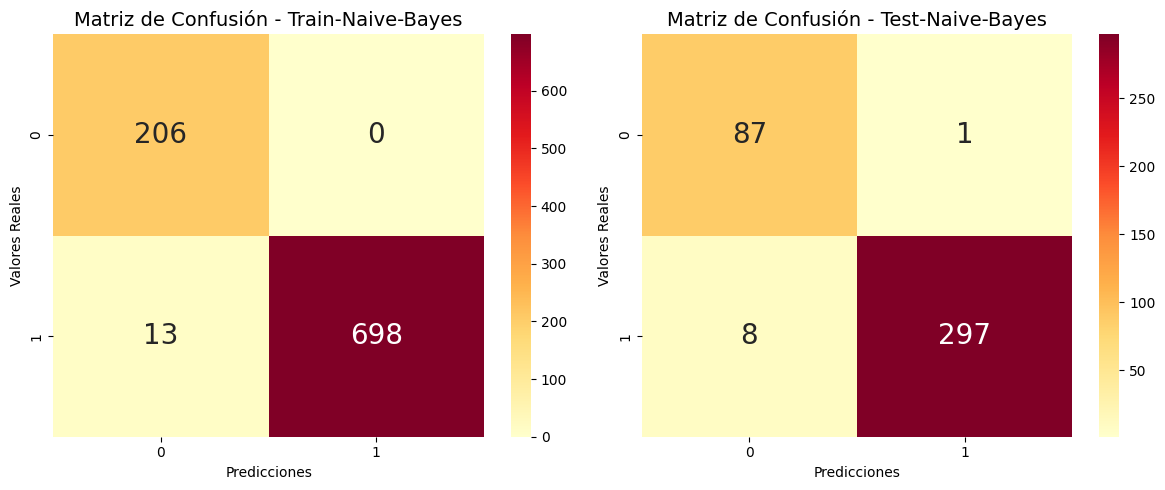

,Naive-Bayes_train,Naive-Bayes_test
accuracy,0.985823,0.977099
recall,0.981716,0.973770
specificity,1.000000,0.988636
precision,1.000000,0.996644
f1,0.990774,0.985075


In [17]:
# para buscar los archivos del modulo
import sys
sys.path.append("/content/drive/MyDrive/Machine_learning/mis_modulos")

# importar el modulo y recargarlo si se hacen cambios, sin necesidad de reiniciar.
import importlib, evaluacion as ev
importlib.reload(ev)

# función de evaluación del modulo evaluación
ev.evaluacion_modelo(modelo_naive, X_train, y_train, X_test, y_test, nombre_modelo= "Naive-Bayes", graficar = True)

# <FONT SIZE=5 COLOR="purple"> 5. Ejemplo práctico de Naive-Bayes 2 </FONT>

- Esta es una base clásica para ilustrar algunas técnicas estadísticas y de *machine learning*.

- El conjunto de datos tiene registros de 4 variables de tres especies de flores iris: *setosa*, *virginica* y *versicolor*

   - ***Sepal.Lenght***
   - ***Sepal Width***
   - ***Petal.Length***
   - ***Petal.Width***

<center><img src="https://1938.com.es/assets/html_ejemplos/iris-machinelearning.png" width="650" height="200"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente:https://1938.com.es/assets/html_ejemplos/iris-machinelearning.png    </FONT> <figcaption></center>
<br>

In [18]:
from sklearn.datasets  import load_iris
iris = load_iris()
iris = pd.DataFrame(data=iris.data, columns = iris.feature_names)
iris["species"] = 50*["setosa"] + 50*["versicolor"] + 50*["virginica"]
iris.head(6)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa


In [19]:
# codificar la variable objetivo
le = LabelEncoder()
iris["species_encoded"] = le.fit_transform(iris["species"])

In [20]:
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_encoded
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [21]:
print(le.classes_)      # ['setosa' 'versicolor' 'virginica']
print(le.transform(le.classes_)) # [0 1 2]

['setosa' 'versicolor' 'virginica']
[0 1 2]


In [22]:
# Dividir en dos conjuntos
# las variables predictoras
X = iris.iloc[: , 0:4]
# la variable objetivo
y = iris["species_encoded"]
# conjunto de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

In [23]:
# definimos el modelo de vecinos más cercanos
modelo_naive = Pipeline(steps=[
      ('scaler', StandardScaler()),
      ('classifier', GaussianNB())
      ])
# entrenamos el modelo
modelo_naive.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('classifier', GaussianNB())])

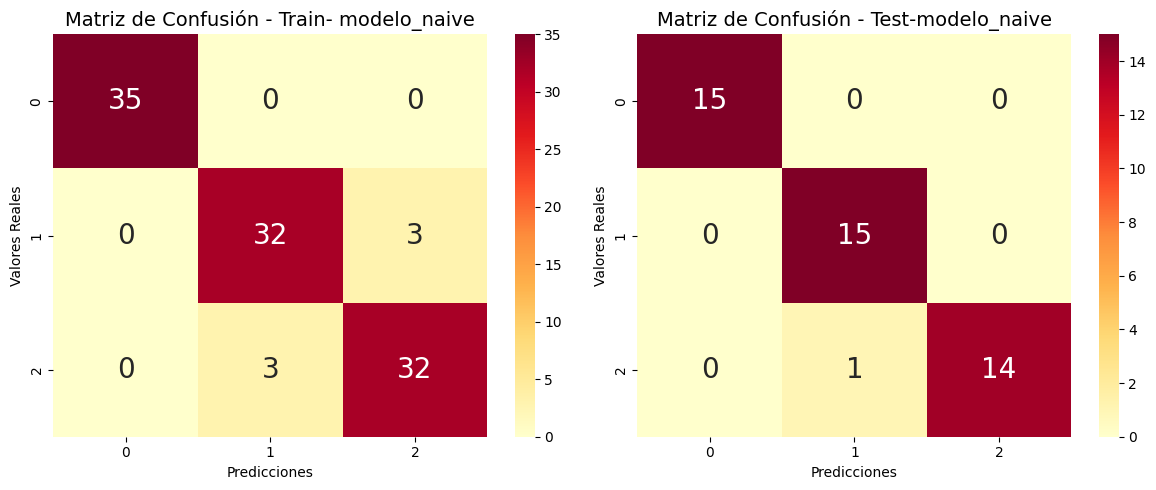

In [24]:
# definir las predicciones en conjuntos de train y test
y_pred_train = modelo_naive.predict(X_train)
y_pred_test  = modelo_naive.predict(X_test)
# matrices de confusión
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)
# ejes para gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# matriz de confusión en train
sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
axes[0].set_title('Matriz de Confusión - Train- modelo_naive', fontsize=14)
axes[0].set_xlabel('Predicciones')
axes[0].set_ylabel('Valores Reales')
# matriz de confusión en test
sns.heatmap(pd.DataFrame(cm_test),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':20},
              ax=axes[1])
axes[1].set_title('Matriz de Confusión - Test-modelo_naive', fontsize=14)
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Valores Reales')
plt.tight_layout()
plt.show()

In [25]:
# hacer el classification_report
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.91      0.91      0.91        35
           2       0.91      0.91      0.91        35

    accuracy                           0.94       105
   macro avg       0.94      0.94      0.94       105
weighted avg       0.94      0.94      0.94       105

